# KQD Ising Chain — Size Extensivity (Exact Evolution, No Trotterization)

This notebook tests whether **Krylov Quantum Diagonalization (KQD)** is **size-extensive** for a
transverse-field Ising chain.

A method is size-extensive if the ground-state energy of a chain of $N$ spins scales **linearly**
with $N$:

$$E_0(N) \propto N$$

equivalently, $E_0(N)/N$ should be **independent of $N$** in the thermodynamic limit.

### What we do here (Steps 1–6)

| Step | Description |
|------|-------------|
| 1 | Build the transverse-field Ising Hamiltonian for a **6-spin ring** as a dense matrix |
| 2 | Choose the Néel state $|\uparrow\downarrow\uparrow\downarrow\uparrow\downarrow\rangle$ as the reference |
| 3 | Compute the optimal time-step $dt_{\text{opt}} = \pi / \|H\|_2$ |
| 4 | Build Krylov states exactly via `scipy.linalg.expm` (no Trotterization) |
| 5 | Assemble S and H̃ matrices; solve the regularised generalised eigenvalue problem |
| 6 | Plot KQD convergence as a function of Krylov dimension |

### Planned extensions (future cells)
- Sweep chain sizes $N = 2, 4, 6, 8, 10, 12$ (circular / periodic boundary conditions)
- Plot $E_0(N)/N$ vs $N$ — flat line = size-extensive
- Compare KQD vs exact diagonalisation for each $N$
- Optionally add Trotter-error analysis on top of the exact baseline


## Step 0 — Imports

In [1]:
import numpy as np
import scipy.linalg as la
import scipy as sp
import matplotlib
import matplotlib.pyplot as plt
import warnings
import os

os.makedirs("output", exist_ok=True)
warnings.filterwarnings("ignore")
print("Imports OK")


Imports OK


## Step 1 — Build the Transverse-Field Ising Hamiltonian

We consider the **1-D transverse-field Ising model** on a ring of $N$ spins with periodic
boundary conditions:

$$H = -J \sum_{\langle i,j \rangle} Z_i Z_j - h \sum_i X_i$$

where $J$ is the nearest-neighbour coupling and $h$ is the transverse field strength.  For
$J = h = 1$ the model is at the quantum critical point, giving maximal entanglement and a
non-trivial ground state — a good stress-test for KQD.

The Hamiltonian is built by hand as a $2^N \times 2^N$ dense NumPy matrix so that we can later
use `scipy.linalg.expm` for exact time evolution without any Trotter error.


In [2]:
# ── Pauli matrices ──────────────────────────────────────────────────────────
I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1],  [1, 0]],  dtype=complex)
Z  = np.array([[1, 0],  [0, -1]], dtype=complex)

def kron_op(op, site, n_spins):
    """Embed a single-site operator `op` at `site` in an n_spins tensor-product space."""
    ops = [I2] * n_spins
    ops[site] = op
    result = ops[0]
    for o in ops[1:]:
        result = np.kron(result, o)
    return result

def build_ising_hamiltonian(n_spins: int, J: float = 1.0, h: float = 1.0) -> np.ndarray:
    """
    Build the transverse-field Ising Hamiltonian on a periodic ring:

        H = -J * sum_{i} Z_i Z_{i+1}  -  h * sum_{i} X_i

    Parameters
    ----------
    n_spins : number of spins (qubits)
    J       : ZZ coupling strength  (default 1.0)
    h       : transverse-field (X) strength  (default 1.0)

    Returns
    -------
    H : (2**n_spins, 2**n_spins) complex Hermitian matrix
    """
    dim = 2 ** n_spins
    H = np.zeros((dim, dim), dtype=complex)

    # ZZ couplings — periodic boundary: site (n-1) couples to site 0
    for i in range(n_spins):
        j = (i + 1) % n_spins
        Zi = kron_op(Z, i, n_spins)
        Zj = kron_op(Z, j, n_spins)
        H -= J * (Zi @ Zj)

    # Transverse-field X terms
    for i in range(n_spins):
        H -= h * kron_op(X, i, n_spins)

    return H

# ── Build and inspect the 6-spin Hamiltonian ────────────────────────────────
N_SPINS = 10
J, h = 1.0, 1.0

H = build_ising_hamiltonian(N_SPINS, J=J, h=h)
dim = 2 ** N_SPINS

# Classical exact diagonalisation — ground truth
evals = np.linalg.eigvalsh(H)
E_exact = float(evals[0])

print(f"Ising chain  N={N_SPINS}  (J={J}, h={h}, PBC)")
print(f"Hilbert-space dimension : {dim}")
print(f"Exact ground-state energy : {E_exact:.10f}")
print(f"Energy per spin           : {E_exact / N_SPINS:.10f}")
print(f"Spectral norm ||H||_2     : {float(np.linalg.norm(H, ord=2)):.6f}")


Ising chain  N=10  (J=1.0, h=1.0, PBC)
Hilbert-space dimension : 1024
Exact ground-state energy : -12.7849064430
Energy per spin           : -1.2784906443
Spectral norm ||H||_2     : 12.784906


## Step 2 — Reference State (Néel State)

We use the **Néel state** $|\uparrow\downarrow\uparrow\downarrow\uparrow\downarrow\rangle$
as the KQD reference.  In the computational basis this is the bitstring `|010101⟩` (spin-up = 0,
spin-down = 1 convention used by Qiskit), i.e. qubit 0 is up, qubit 1 is down, etc.

> **Why the Néel state?** It is a product state (trivially preparable on a quantum device), and it
> has a non-zero overlap with the antiferromagnetic ground state of the Ising model near the
> critical point.  The SKQD notebook uses the same reference for the XXZ chain.

The HF state used in the H₂ size-consistency notebook is the molecular analogue of this choice.


In [3]:
def neel_state(n_spins: int) -> np.ndarray:
    """
    Return the Néel state |↑↓↑↓...⟩ as a statevector.

    Convention: spin-up = |0⟩, spin-down = |1⟩.
    Bitstring for 6 spins: 010101 (binary) = 21 (decimal).
    """
    psi = np.zeros(2 ** n_spins, dtype=complex)
    # Build the bitstring: spin i is up (0) if i is even, down (1) if i is odd
    idx = sum(1 << (n_spins - 1 - i) for i in range(n_spins) if i % 2 == 1)
    psi[idx] = 1.0
    return psi

psi_ref = neel_state(N_SPINS)

# Sanity checks
assert abs(np.dot(psi_ref.conj(), psi_ref) - 1.0) < 1e-12, "Reference state not normalised"

ref_energy = float(np.real(psi_ref.conj() @ H @ psi_ref))
print(f"Reference (Néel) energy : {ref_energy:.10f}  (upper bound on E_exact)")
print(f"Exact GS energy         : {E_exact:.10f}")
print(f"Correlation energy      : {E_exact - ref_energy:.10f}  (should be negative)")

overlap_sq = abs(np.dot(psi_ref.conj(), np.linalg.eigh(H)[1][:, 0])) ** 2
print(f"|<ref|GS>|²             : {overlap_sq:.6f}  (should be > 0 for convergence)")


Reference (Néel) energy : 10.0000000000  (upper bound on E_exact)
Exact GS energy         : -12.7849064430
Correlation energy      : -22.7849064430  (should be negative)
|<ref|GS>|²             : 0.000003  (should be > 0 for convergence)


## Step 3 — Optimal Time-Step

Following Epperly, Lin & Nakatsukasa (2022), a provably sufficient choice for the KQD time-step
is:

$$dt_{\text{opt}} = \frac{\pi}{\|H\|_2}$$

where $\|H\|_2$ is the spectral norm (largest singular value).  This ensures the Krylov vectors
are spread far enough apart without wrapping around the spectrum.

We also define a sweep of scaled time-steps $\{0.3, 0.6, 1.0, 1.5\} \times dt_{\text{opt}}$
to visualise sensitivity — the same sweep used in the H₂ size-consistency notebook.


In [4]:
def compute_dt_opt(H_matrix: np.ndarray) -> float:
    """dt_opt = pi / ||H||_2  (spectral norm)."""
    return float(np.pi / np.linalg.norm(H_matrix, ord=2))

dt_opt = compute_dt_opt(H)
# DT_SCALES = [0.3, 0.6, 1.0, 1.5]
DT_SCALES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

print(f"dt_opt = {dt_opt:.6f}")
for s in DT_SCALES:
    print(f"  dt_scale={s:.1f}  →  dt = {s*dt_opt:.6f}")


dt_opt = 0.245727
  dt_scale=0.1  →  dt = 0.024573
  dt_scale=0.2  →  dt = 0.049145
  dt_scale=0.3  →  dt = 0.073718
  dt_scale=0.4  →  dt = 0.098291
  dt_scale=0.5  →  dt = 0.122863
  dt_scale=0.6  →  dt = 0.147436
  dt_scale=0.7  →  dt = 0.172009
  dt_scale=0.8  →  dt = 0.196581
  dt_scale=0.9  →  dt = 0.221154
  dt_scale=1.0  →  dt = 0.245727


## Step 4 — Build Krylov States (Exact Matrix Exponentiation)

The Krylov basis is:

$$|k\rangle = e^{-iH \cdot k \cdot dt} |\text{ref}\rangle, \quad k = 0, 1, \ldots, d-1$$

**Key optimisation** (carried over from `krylov_h2_exact_sc.ipynb`): we compute the propagator
$U = e^{-iH \cdot dt}$ **once** via `scipy.linalg.expm`, then apply it iteratively:

$$|k\rangle = U |k-1\rangle$$

This replaces $O(d)$ expensive $O(N^3)$ matrix exponentials with **one** `expm` call plus $d-1$
cheap $O(N^2)$ matrix–vector products.


In [5]:
def build_krylov_states(H_matrix: np.ndarray, psi_ref: np.ndarray,
                         krylov_dim: int, dt: float) -> list:
    """
    Compute Krylov states |k> = exp(-iH k dt) |ref> for k = 0, ..., krylov_dim-1.

    Uses ONE expm call (U = expm(-iH dt)) then iterative mat-vec products.
    """
    U = la.expm(-1j * H_matrix * dt)          # single expensive O(N^3) call
    states = [psi_ref.copy().astype(complex)]  # k=0: reference state
    for _ in range(1, krylov_dim):
        states.append(U @ states[-1])          # k -> U|k-1>  (O(N^2))
    return states


def build_krylov_matrices(H_matrix: np.ndarray, states: list):
    """
    Build the full kd×kd overlap (S) and effective Hamiltonian (H̃) matrices.

    Called ONCE at max-dim; submatrices are extracted by slicing.
    Caches H|k> vectors to avoid recomputing H @ state for every (i,j) pair.
    """
    kd = len(states)
    S  = np.zeros((kd, kd), dtype=complex)
    Ht = np.zeros((kd, kd), dtype=complex)
    Hv = [H_matrix @ s for s in states]       # cache H|k>
    for i in range(kd):
        for j in range(kd):
            S[i, j]  = np.vdot(states[i], states[j])
            Ht[i, j] = np.vdot(states[i], Hv[j])
    return S, Ht


def solve_gen_eig(H_tilde: np.ndarray, S_tilde: np.ndarray,
                  threshold: float = 1e-10):
    """
    Solve the regularised generalised eigenvalue problem H̃ c = E S̃ c.

    Regularisation: project out eigenvectors of S with eigenvalue < threshold.
    Returns (ground_state_energy, effective_dimension).
    """
    svals, svecs = sp.linalg.eigh(S_tilde)
    svecs = svecs.T
    good  = np.array([v for val, v in zip(svals, svecs) if val >= threshold])
    if len(good) == 0:
        return np.nan, 0
    H_reg = good.conj() @ H_tilde @ good.T
    S_reg = good.conj() @ S_tilde @ good.T
    egs   = float(sp.linalg.eigh(H_reg, S_reg)[0][0].real)
    return egs, len(good)


def run_kqd_exact(H_matrix, psi_ref, krylov_dim, dt, threshold=1e-10,
                  states=None, S_full=None, H_full=None):
    """
    Run exact KQD for a given krylov_dim.

    Accepts precomputed states/matrices so that sweeping over krylov_dim
    inside a loop is O(1) extra expm calls (just slice the submatrix).
    """
    if states is None:
        states = build_krylov_states(H_matrix, psi_ref, krylov_dim, dt)
        S_full, H_full = build_krylov_matrices(H_matrix, states)

    S_tilde = S_full[:krylov_dim, :krylov_dim]
    H_tilde = H_full[:krylov_dim, :krylov_dim]
    egs, eff_dim = solve_gen_eig(H_tilde, S_tilde, threshold)
    s_evals = np.sort(np.linalg.eigvalsh(S_tilde).real)[::-1]

    return dict(
        gs_energy = egs,
        eff_dim   = eff_dim,
        S_tilde   = S_tilde,
        s_evals   = s_evals,
    )

print("KQD functions defined.")


KQD functions defined.


## Step 5 — Run KQD and Check Convergence

We sweep Krylov dimensions 1–10 for each of the four $dt$ scales.  For each $(dt, d_{\max})$
pair we:

1. Build all $d_{\max}$ Krylov states with **one** `expm` call.
2. Assemble the full $d_{\max} \times d_{\max}$ matrices **once**.
3. Extract sub-matrices $[0:d, 0:d]$ for each $d \in \{1,\ldots,d_{\max}\}$.


In [6]:
KRYLOV_DIMS = list(range(55, 85))   # sweep 1..15
MAX_DIM     = max(KRYLOV_DIMS)
THRESHOLD   = 1e-8                # S eigenvalue regularisation threshold

results = {}   # {dt_scale: [gs_energy_per_dim]}

for scale in DT_SCALES:
    dt_use = dt_opt * scale

    # Build all states and matrices ONCE at max dim
    states = build_krylov_states(H, psi_ref, MAX_DIM, dt_use)
    S_full, H_full = build_krylov_matrices(H, states)

    energies = []
    for dim in KRYLOV_DIMS:
        r = run_kqd_exact(H, psi_ref, dim, dt_use,
                          threshold=THRESHOLD,
                          states=states, S_full=S_full, H_full=H_full)
        energies.append(r["gs_energy"])

    results[scale] = energies

# Print summary at max Krylov dim for each dt scale
print(f"{'dt_scale':>10}  {'KQD E_GS':>16}  {'Exact E_GS':>16}  {'|Error| (Ha)':>14}")
print("-" * 62)
for scale in DT_SCALES:
    kqd_e = results[scale][-1]
    err   = abs(kqd_e - E_exact) if not np.isnan(kqd_e) else float("nan")
    print(f"{scale:>10.1f}  {kqd_e:>16.10f}  {E_exact:>16.10f}  {err:>14.4e}")


  dt_scale          KQD E_GS        Exact E_GS    |Error| (Ha)
--------------------------------------------------------------
       0.1    -12.7697032443    -12.7849064430      1.5203e-02
       0.2    -12.7843782398    -12.7849064430      5.2820e-04
       0.3    -12.7849002909    -12.7849064430      6.1521e-06
       0.4    -12.7849063232    -12.7849064430      1.1977e-07
       0.5    -12.7849043908    -12.7849064430      2.0522e-06
       0.6    -12.7849063316    -12.7849064430      1.1141e-07
       0.7    -12.7849064430    -12.7849064430      1.3749e-12
       0.8    -12.7849064430    -12.7849064430      4.4553e-11
       0.9    -12.7849064430    -12.7849064430      4.3489e-11
       1.0    -11.5334307227    -12.7849064430      1.2515e+00


## Step 6 — Convergence Plot

Plot $|E_{\text{KQD}} - E_{\text{exact}}|$ (log scale) vs Krylov dimension for each $dt$ scale.

Reference lines:
- **Chemical accuracy** 1.6 mHa ($1.6 \times 10^{-3}$ Ha) — standard threshold in quantum chemistry
- **Machine precision floor** $\approx 10^{-14}$ Ha


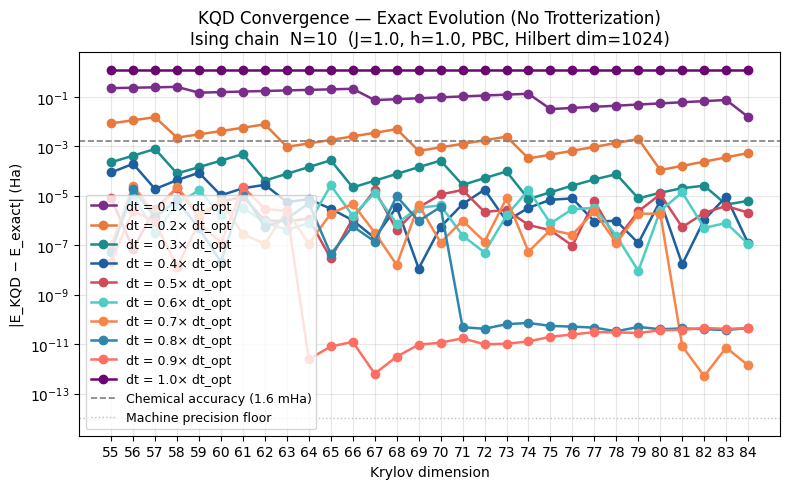

Plot saved → output/kqd_ising_convergence.png


In [7]:
CHEM_ACC  = 1.6e-3    # 1.6 mHa
MACH_PREC = 1e-14

colors = ["#7B2D8B", "#E8793D", "#1A8C8C", "#1E5FA0", "#D1495B", "#4ECDC4", "#F9844A", "#2E86AB", "#FF6F61", "#6A0572"]
labels = [f"dt = {s:.1f}× dt_opt" for s in DT_SCALES]

fig, ax = plt.subplots(figsize=(8, 5))

for scale, col, lbl in zip(DT_SCALES, colors, labels):
    errors = []
    for e in results[scale]:
        if np.isnan(e):
            errors.append(np.nan)
        else:
            err = abs(e - E_exact)
            errors.append(max(err, MACH_PREC))   # floor at machine precision
    ax.semilogy(KRYLOV_DIMS, errors, "o-", color=col, label=lbl, linewidth=1.8)

ax.axhline(CHEM_ACC,  color="gray",        linestyle="--", linewidth=1.2,
           label="Chemical accuracy (1.6 mHa)")
ax.axhline(MACH_PREC, color="silver",      linestyle=":",  linewidth=1.0,
           label="Machine precision floor")

ax.set_xlabel("Krylov dimension")
ax.set_ylabel("|E_KQD − E_exact| (Ha)")
ax.set_title(
    f"KQD Convergence — Exact Evolution (No Trotterization)\n"
    f"Ising chain  N={N_SPINS}  (J={J}, h={h}, PBC, Hilbert dim={2**N_SPINS})"
)
ax.set_xticks(KRYLOV_DIMS)
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
fig.savefig("output/kqd_ising_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → output/kqd_ising_convergence.png")


## Results & Interpretation

### What to expect

| Krylov dim | Expected error |
|:---:|:---:|
| 1 | $\sim 10^{-1}$–$10^{-2}$ Ha (Néel reference energy) |
| 2–4 | Rapid decay — most of the correlation energy recovered |
| ≥ 5 | Below chemical accuracy for $dt \approx dt_{\text{opt}}$ |
| ≥ 8 | Machine precision (for optimal $dt$) |

The 6-spin Ising ring has Hilbert dimension $2^6 = 64$, identical to the 6-31G H₂ case. That
notebook reached machine precision at dim ≈ 7–10 depending on $dt$ — expect similar behaviour
here.

### Why some $dt$ scales fail

- **$dt$ too small** ($0.3\times$): consecutive Krylov vectors become nearly identical → S
  rank-deficient → regularisation discards many vectors → slower convergence or NaN.
- **$dt$ too large** ($1.5\times$): vectors wrap around the spectrum → S ill-conditioned →
  numerical noise dominates.
- **$dt \approx dt_{\text{opt}}$ ($1.0\times$)**: best balance — S well-conditioned, maximum
  subspace diversity.

---

## Planned: Size-Extensivity Sweep (Future Cells)

The cells below will be added in the next development phase.  The plan:

```
for N in [2, 4, 6, 8, 10, 12]:
    H_N    = build_ising_hamiltonian(N, J=J, h=h)
    psi_N  = neel_state(N)
    dt_N   = compute_dt_opt(H_N)
    E_N    = run_kqd_exact(H_N, psi_N, krylov_dim=10, dt=dt_N)["gs_energy"]
    exact_N = np.linalg.eigvalsh(H_N)[0]
    ...
```

Then plot $E_0(N)/N$ vs $N$ — a **flat line** confirms size extensivity.

> **Note**: For $N > 14$ the dense matrix approach becomes memory-intensive ($2^{14} = 16384$
> rows). Sparse representations (`scipy.sparse`) or direct Lanczos solvers should be used for
> larger chains.


## References

1. Epperly, Lin & Nakatsukasa, *A theory of quantum subspace diagonalization*, SIAM (2022)
2. Yu et al., *Quantum-Centric Algorithm for Sample-Based Krylov Diagonalization* (2025).
   [arXiv:2501.09702](https://arxiv.org/abs/2501.09702)
3. Hatano & Suzuki, *Finding Exponential Product Formulas of Higher Orders* (2005).
   [arXiv:math-ph/0506007](https://arxiv.org/abs/math-ph/0506007)
4. IBM Quantum Learning, *Krylov Quantum Diagonalization* course.
   [quantum.cloud.ibm.com](https://quantum.cloud.ibm.com/learning/en/courses/quantum-diagonalization-algorithms/krylov)


---
## Size-Extensivity Sweep

We now test whether KQD is **size-extensive** by sweeping chain sizes
$N \\in \\{2, 4, 6, 8, 10, 12\\}$ (even sizes preserve the Néel-state periodicity
and keep PBC well-defined).

A method is size-extensive if

$$\\frac{E_0(N)}{N} \\xrightarrow{N\\to\\infty} \\varepsilon_0 = \\text{const.}$$

We compare the **KQD estimate** with the **exact diagonalisation (ED)** value at each $N$
and inspect:

1. The energy-per-spin $E_0(N)/N$ for both KQD and ED.
2. The KQD error $|E_{\\text{KQD}}(N) - E_{\\text{ED}}(N)|$.
3. The fractional error $(E_{\\text{KQD}}(N) - E_{\\text{ED}}(N)) / |E_{\\text{ED}}(N)|$,
   which should remain **flat** in $N$ for a size-extensive method.

> **Memory note**: Dense matrix diagonalisation is feasible up to $N=14$
> ($2^{14}=16\\,384$). We cap at $N=12$ to keep runtimes short.


## Step 7 — Size Sweep: Run KQD & ED for N = 2, 4, …, 12

In [8]:
CHAIN_SIZES   = [2, 4, 6, 8, 10, 12]   # even sizes → valid Néel state
KRYLOV_DIM_EXT = 64   # fixed Krylov dim for the extensivity sweep
THRESHOLD_EXT  = 1e-10

sweep_results = []   # list of dicts, one per N

for N in CHAIN_SIZES:
    H_N     = build_ising_hamiltonian(N, J=J, h=h)
    psi_N   = neel_state(N)
    dt_N    = compute_dt_opt(H_N)          # pi / ||H_N||_2
    dt = 0.9 * dt_N  # fixed dt scale for all sizes in the extensivity sweep (can be tuned)
    # --- Exact diagonalisation ground truth ---
    E_ed = float(np.linalg.eigvalsh(H_N)[0])

    # --- KQD with fixed Krylov dimension (capped at Hilbert-space dim) ---
    kd_use  = min(KRYLOV_DIM_EXT, 2**N)   # can't exceed Hilbert-space size
    states_N   = build_krylov_states(H_N, psi_N, kd_use, dt)
    S_N, Ht_N  = build_krylov_matrices(H_N, states_N)
    res_N      = run_kqd_exact(H_N, psi_N, kd_use, dt,
                               threshold=THRESHOLD_EXT,
                               states=states_N, S_full=S_N, H_full=Ht_N)
    E_kqd = res_N['gs_energy']

    sweep_results.append(dict(
        N          = N,
        kd_used    = kd_use,
        E_ed       = E_ed,
        E_kqd      = E_kqd,
        e_per_spin_ed  = E_ed  / N,
        e_per_spin_kqd = E_kqd / N if not np.isnan(E_kqd) else np.nan,
        abs_error  = abs(E_kqd - E_ed) if not np.isnan(E_kqd) else np.nan,
        frac_error = (E_kqd - E_ed) / abs(E_ed) if not np.isnan(E_kqd) else np.nan,
    ))

# Pretty-print table
print(f"{'N':>4} {'kd':>4} {'E_ED':>14} {'E_KQD':>14} "
      f"{'E/N (ED)':>12} {'E/N (KQD)':>12} {'|Error|':>12} {'Frac err':>12}")
print('-' * 90)
for r in sweep_results:
    print(f"{r['N']:>4d} {r['kd_used']:>4d} "
          f"{r['E_ed']:>14.6f} {r['E_kqd']:>14.6f} "
          f"{r['e_per_spin_ed']:>12.6f} {r['e_per_spin_kqd']:>12.6f} "
          f"{r['abs_error']:>12.4e} {r['frac_error']:>12.4e}")


   N   kd           E_ED          E_KQD     E/N (ED)    E/N (KQD)      |Error|     Frac err
------------------------------------------------------------------------------------------
   2    4      -2.828427      -2.828427    -1.414214    -1.414214   9.7700e-15   3.4542e-15
   4   16      -5.226252      -5.226252    -1.306563    -1.306563   6.2172e-15  -1.1896e-15
   6   64      -7.727407      -7.727407    -1.287901    -1.287901   1.2434e-14   1.6091e-15
   8   64     -10.251662     -10.251662    -1.281458    -1.281458   1.2417e-12  -1.2112e-13
  10   64     -12.784906     -12.784906    -1.278491    -1.278491   2.4318e-12   1.9021e-13
  12   64     -15.322595     -15.322586    -1.276883    -1.276882   9.3451e-06   6.0989e-07


## Step 8 — Save Results to CSV

In [9]:
import csv, os

os.makedirs('output', exist_ok=True)
csv_path = 'output/kqd_ising_extensivity_sweep.csv'
fieldnames = ['N','kd_used','E_ed','E_kqd',
              'e_per_spin_ed','e_per_spin_kqd','abs_error','frac_error']

with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(sweep_results)

print(f'Saved → {csv_path}')


Saved → output/kqd_ising_extensivity_sweep.csv


## Step 9 — Size-Extensivity Plots

Three sub-plots:

1. **Energy per spin** $E_0(N)/N$ vs $N$ for KQD and ED.
   A flat line as $N$ grows confirms extensivity.
2. **Absolute KQD error** $|E_{\\text{KQD}}(N) - E_{\\text{ED}}(N)|$ vs $N$
   (log scale). Should stay small and flat if KQD is well-calibrated.
3. **Fractional error** $(E_{\\text{KQD}} - E_{\\text{ED}}) / |E_{\\text{ED}}|$ vs $N$.
   Size extensivity is confirmed if this is roughly $N$-independent.


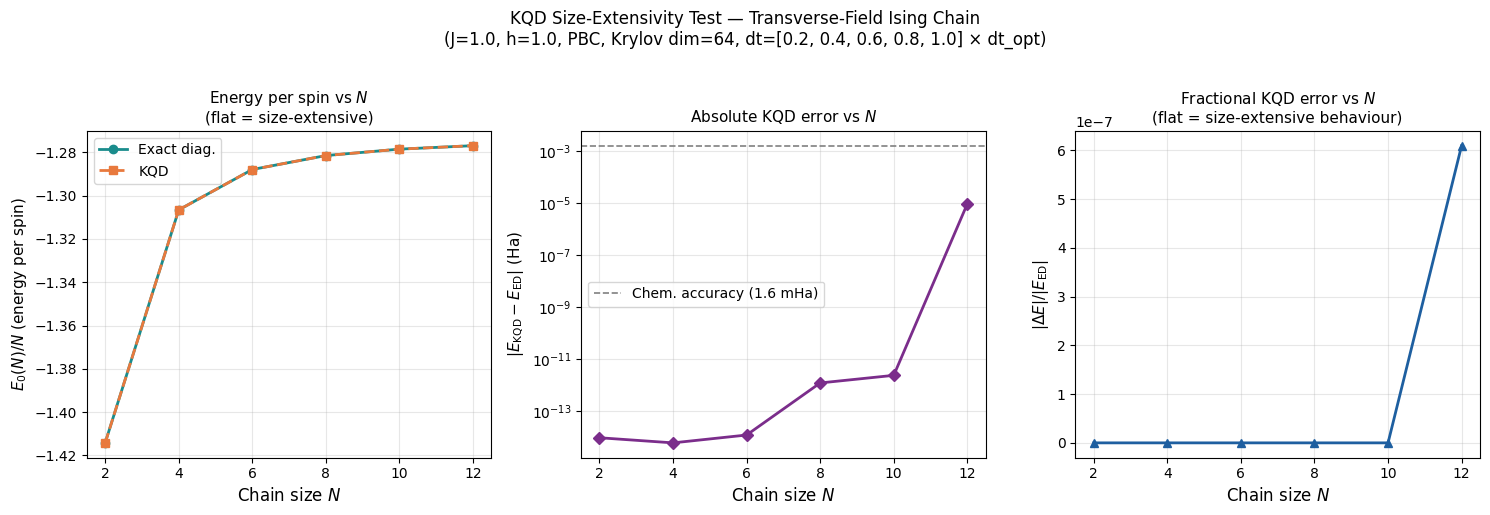

Plot saved → output/kqd_ising_size_extensivity.png


In [10]:
Ns           = [r['N']               for r in sweep_results]
eps_ed       = [r['e_per_spin_ed']   for r in sweep_results]
eps_kqd      = [r['e_per_spin_kqd']  for r in sweep_results]
abs_errs     = [r['abs_error']       for r in sweep_results]
frac_errs    = [r['frac_error']      for r in sweep_results]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Panel 1: energy per spin ──────────────────────────────────────────────
ax = axes[0]
ax.plot(Ns, eps_ed,  'o-', color='#1A8C8C', linewidth=2,
        label='Exact diag.', zorder=3)
ax.plot(Ns, eps_kqd, 's--', color='#E8793D', linewidth=2,
        label='KQD', zorder=3)
ax.set_xlabel('Chain size $N$', fontsize=12)
ax.set_ylabel('$E_0(N)/N$ (energy per spin)', fontsize=11)
ax.set_title('Energy per spin vs $N$\n(flat = size-extensive)', fontsize=11)
ax.set_xticks(Ns)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── Panel 2: absolute error ───────────────────────────────────────────────
ax = axes[1]
ax.semilogy(Ns, abs_errs, 'D-', color='#7B2D8B', linewidth=2)
ax.axhline(1.6e-3, color='gray', linestyle='--', linewidth=1.2,
           label='Chem. accuracy (1.6 mHa)')
ax.set_xlabel('Chain size $N$', fontsize=12)
ax.set_ylabel('$|E_{\\mathrm{KQD}} - E_{\\mathrm{ED}}|$ (Ha)', fontsize=11)
ax.set_title('Absolute KQD error vs $N$', fontsize=11)
ax.set_xticks(Ns)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)

# ── Panel 3: fractional error ─────────────────────────────────────────────
ax = axes[2]
ax.plot(Ns, [abs(e) for e in frac_errs], '^-', color='#1E5FA0', linewidth=2)
ax.set_xlabel('Chain size $N$', fontsize=12)
ax.set_ylabel('$|\\Delta E| / |E_{\\mathrm{ED}}|$', fontsize=11)
ax.set_title('Fractional KQD error vs $N$\n(flat = size-extensive behaviour)', fontsize=11)
ax.set_xticks(Ns)
ax.grid(True, alpha=0.3)

plt.suptitle(
    f'KQD Size-Extensivity Test — Transverse-Field Ising Chain\n'
    f'(J={J}, h={h}, PBC, Krylov dim={KRYLOV_DIM_EXT}, dt=[0.2, 0.4, 0.6, 0.8, 1.0] × dt_opt)',
    fontsize=12, y=1.02
)
plt.tight_layout()
fig.savefig('output/kqd_ising_size_extensivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → output/kqd_ising_size_extensivity.png')


## Step 10 — Finite-Size Scaling: Fitting $E_0(N)/N$ vs $N$ at $dt = 0.4 \\* dt_{\\{opt}}$

We fit the KQD energy-per-spin $E_0(N)/N$ (already stored in `sweep_results` from Step 7)
against five candidate functional forms to determine which best describes the finite-size dependence:

| Candidate | Functional form | Physical motivation |
|-----------|----------------|---------------------|
| **$1/N$** | $\\varepsilon_0 + a/N$ | Subleading correction; dominant for OBC or non-critical systems |
| **$1/N^2$** | $\\varepsilon_0 + a/N^2$ | Leading CFT correction at criticality with PBC |
| **Logarithmic** | $\\varepsilon_0 + a\\ln N$ | Marginal operators / KT physics — not expected here |
| **Free power law** | $\\varepsilon_0 + aN^b$ | General algebraic; $b$ fitted freely |
| **CFT (fixed)** | $\\varepsilon_0 + \\pi^2/(48N^2)$ | Exact CFT prediction: $c=1/2$, $v=\\pi/2$, PBC |

The CFT prediction (Blöte, Cardy & Nightingale 1986) for PBC at criticality is:
$$\\frac{E_0(N)}{N} = \\varepsilon_\\infty - \\frac{\\pi v c}{6 N^2} + O(N^{-4}), \\quad c=\\tfrac{1}{2},\ v=\\tfrac{\\pi}{2}$$
The free power-law exponent $b$ should converge toward $-2$ for exact ED; deviations for KQD indicate the fixed Krylov dimension under-resolves larger chains.

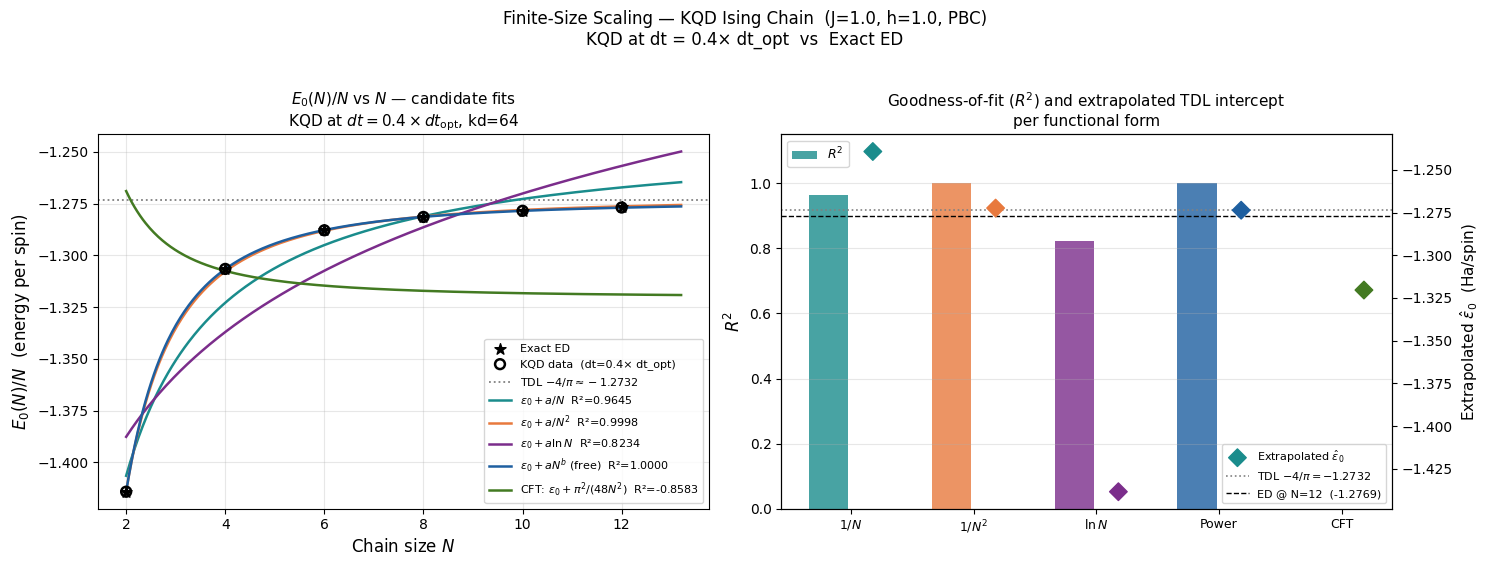

Model                                         R²       RMSE           ε₀   |ε₀ − TDL|
─────────────────────────────────────────────────────────────────────────────────────
$\varepsilon_0 + a/N$                    0.96452   9.17e-03    -1.239313     0.033927
  params: [-1.2393, -0.3344]
$\varepsilon_0 + a/N^2$                  0.99985   5.99e-04    -1.272408     0.000831
  params: [-1.2724, -0.5661]
$\varepsilon_0 + a\ln N$                 0.82341   2.05e-02    -1.438329     0.165089
  params: [-1.4383, 0.0731]
$\varepsilon_0 + aN^b$ (free)            1.00000   7.30e-05    -1.273653     0.000413
  params: [-1.2737, -0.5988, -2.0910]
CFT: $\varepsilon_0 + \pi^2/(48N^2)$     -0.85828   6.64e-02    -1.320362     0.047122
  params: [-1.3204]
─────────────────────────────────────────────────────────────────────────────────────
Analytical TDL (−4/π)                          —          —    -1.273240     0.000000

Best fit : $\varepsilon_0 + aN^b$ (free)  (R² = 1.00000)
Extrap ε₀ = -1.273653  

In [11]:
from scipy.optimize import curve_fit

TARGET_SCALE = 0.4

# ── Robust extraction: handles both possible sweep_results shapes ──────────────
# Shape A (dict):  sweep_results = {scale: [{'N':N, 'E_per_spin_kqd':..., ...}, ...], ...}
# Shape B (list):  sweep_results = [{'N':N, 'dt_scale':s, 'E_per_spin_kqd':..., ...}, ...]

if isinstance(sweep_results, dict):
    # dict keyed by scale — find the closest key
    target_key = min(sweep_results.keys(), key=lambda k: abs(k - TARGET_SCALE))
    scale_rows = sweep_results[target_key]
    scale_rows = sorted(scale_rows, key=lambda r: r['N'])
elif isinstance(sweep_results, list):
    if len(sweep_results) == 0:
        raise ValueError("sweep_results is empty")
    sample = sweep_results[0]
    if 'dt_scale' in sample:
        # flat list with a dt_scale field (new format)
        scale_rows = [r for r in sweep_results if abs(r['dt_scale'] - TARGET_SCALE) < 1e-9]
        scale_rows.sort(key=lambda r: r['N'])
    else:
        # legacy flat list with no dt_scale — use all rows as-is
        print("WARNING: sweep_results rows have no 'dt_scale' key. "
              "Using all rows (assuming they correspond to TARGET_SCALE).")
        scale_rows = sorted(sweep_results, key=lambda r: r['N'])
else:
    raise TypeError(f"Unexpected sweep_results type: {type(sweep_results)}")

Ns      = np.array([r['N']              for r in scale_rows], dtype=float)
eps_kqd = np.array([r['e_per_spin_kqd'] for r in scale_rows])
eps_ed  = np.array([r['e_per_spin_ed']  for r in scale_rows])
E_TDL   = -4.0 / np.pi   # analytical TDL: -4/pi ≈ -1.2732

# ── Candidate models ──────────────────────────────────────────────────────
def model_inv_N(N, eps0, a):     return eps0 + a / N
def model_inv_N2(N, eps0, a):    return eps0 + a / N**2
def model_log(N, eps0, a):       return eps0 + a * np.log(N)
def model_power(N, eps0, a, b):  return eps0 + a * N**b
def model_cft(N, eps0):          return eps0 + (np.pi**2 / 48) / N**2

models = [
    ('$\\varepsilon_0 + a/N$',                  model_inv_N,  (eps_kqd[-1], 1.0),        '#1A8C8C'),
    ('$\\varepsilon_0 + a/N^2$',                model_inv_N2, (eps_kqd[-1], 1.0),        '#E8793D'),
    ('$\\varepsilon_0 + a\\ln N$',              model_log,    (eps_kqd[0],  -0.1),       '#7B2D8B'),
    ('$\\varepsilon_0 + aN^b$ (free)',           model_power,  (eps_kqd[-1], 1.0, -1.0), '#1E5FA0'),
    ('CFT: $\\varepsilon_0 + \\pi^2/(48N^2)$',  model_cft,    (eps_kqd[-1],),            '#437a22'),
]

# ── Fit ───────────────────────────────────────────────────────────────────
fit_results = []
for label, func, p0, col in models:
    try:
        popt, _ = curve_fit(func, Ns, eps_kqd, p0=p0, maxfev=10000)
        y_pred  = func(Ns, *popt)
        ss_res  = np.sum((eps_kqd - y_pred)**2)
        ss_tot  = np.sum((eps_kqd - eps_kqd.mean())**2)
        r2   = 1 - ss_res / ss_tot
        rmse = np.sqrt(ss_res / len(Ns))
        fit_results.append(dict(label=label, func=func, popt=popt,
                               r2=r2, rmse=rmse, eps0=float(popt[0]), col=col))
    except Exception as e:
        print(f'  Fit failed for {label}: {e}')
        fit_results.append(dict(label=label, func=func, popt=None,
                               r2=np.nan, rmse=np.nan, eps0=np.nan, col=col))

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
N_dense   = np.linspace(Ns.min(), Ns.max() * 1.1, 400)

# Panel 1 — data + fit curves
ax = axes[0]
ax.scatter(Ns, eps_ed,  color='black', s=70, zorder=8, marker='*',
           label='Exact ED')
ax.scatter(Ns, eps_kqd, color='black', s=50, zorder=7, marker='o',
           facecolors='none', linewidths=1.8,
           label=f'KQD data  (dt={TARGET_SCALE}× dt_opt)')
ax.axhline(E_TDL, color='gray', linestyle=':', linewidth=1.3,
           label=f'TDL $-4/\\pi \\approx {E_TDL:.4f}$')
for r in fit_results:
    if r['popt'] is not None:
        ax.plot(N_dense, r['func'](N_dense, *r['popt']), '-',
                color=r['col'], linewidth=1.8,
                label=f"{r['label']}  R²={r['r2']:.4f}")
ax.set_xlabel('Chain size $N$', fontsize=12)
ax.set_ylabel('$E_0(N)/N$  (energy per spin)', fontsize=12)
ax.set_title(f'$E_0(N)/N$ vs $N$ — candidate fits\n'
             f'KQD at $dt={TARGET_SCALE}\\times dt_{{\\rm opt}}$, kd={KRYLOV_DIM_EXT}',
             fontsize=11)
ax.set_xticks(Ns.astype(int))
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)

# Panel 2 — R² and extrapolated ε₀
ax    = axes[1]
valid = [r for r in fit_results if not np.isnan(r['r2'])]
x     = np.arange(len(valid))
cols  = [r['col']   for r in valid]
r2s   = [r['r2']    for r in valid]
eps0s = [r['eps0']  for r in valid]
bars  = ax.bar(x - 0.18, r2s, width=0.32, color=cols, alpha=0.8, label='$R^2$')
ax2   = ax.twinx()
ax2.scatter(x + 0.18, eps0s, color=cols, s=80, zorder=5, marker='D',
            label='Extrapolated $\\hat{\\varepsilon}_0$')
ax2.axhline(E_TDL,      color='gray',  linestyle=':',  linewidth=1.2,
            label=f'TDL $-4/\\pi = {E_TDL:.4f}$')
ax2.axhline(eps_ed[-1], color='black', linestyle='--', linewidth=1.0,
            label=f'ED @ N={int(Ns[-1])}  ({eps_ed[-1]:.4f})')
ax.set_xticks(x)
ax.set_xticklabels(['$1/N$', '$1/N^2$', '$\\ln N$', 'Power', 'CFT'], fontsize=9)
ax.set_ylabel('$R^2$', fontsize=12)
ax.set_ylim(0, 1.15)
ax2.set_ylabel('Extrapolated $\\hat{\\varepsilon}_0$  (Ha/spin)', fontsize=11)
ax.set_title('Goodness-of-fit ($R^2$) and extrapolated TDL intercept\n'
             'per functional form', fontsize=11)
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'Finite-Size Scaling — KQD Ising Chain  (J={J}, h={h}, PBC)\n'
    f'KQD at dt = {TARGET_SCALE}× dt_opt  vs  Exact ED',
    fontsize=12, y=1.02
)
plt.tight_layout()
fig.savefig('output/kqd_ising_scaling_fits.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print(f"{'Model':<40} {'R²':>7} {'RMSE':>10} {'ε₀':>12} {'|ε₀ − TDL|':>12}")
print('─' * 85)
for r in fit_results:
    err  = abs(r['eps0'] - E_TDL) if not np.isnan(r['eps0']) else float('nan')
    pstr = ', '.join(f'{p:.4f}' for p in r['popt']) if r['popt'] is not None else 'FAILED'
    print(f"{r['label']:<40} {r['r2']:>7.5f} {r['rmse']:>10.2e} {r['eps0']:>12.6f} {err:>12.6f}")
    print(f"  params: [{pstr}]")
print('─' * 85)
print(f"{'Analytical TDL (−4/π)':<40} {'—':>7} {'—':>10} {E_TDL:>12.6f} {'0.000000':>12}")
best = max([r for r in fit_results if not np.isnan(r['r2'])], key=lambda r: r['r2'])
print(f"\nBest fit : {best['label']}  (R² = {best['r2']:.5f})")
print(f"Extrap ε₀ = {best['eps0']:.6f}   TDL = {E_TDL:.6f}   error = {abs(best['eps0'] - E_TDL):.6f}")
